In [42]:
# !pip uninstall -y flax orbax-checkpoint jax jaxlib \
#     ml-dtypes tf-keras tensorflow tensorflow-cpu tensorflow-text \
#     tensorflow-decision-forests keras keras-hub \
#     chex optax fastai spacy tensorstore numba \
#     umap-learn pynndescent librosa shap cuml-cu12 cudf-cu12 dask-cuda

%pip install -U threadpoolctl joblib
#%pip install --force-reinstall numpy==1.26.4
%pip install --upgrade scikit-learn
%pip install -U imbalanced-learn umap-learn

%pip install --upgrade --force-reinstall \
    numpy \
    scipy \
    matplotlib \
    seaborn \
    pandas \
    tensorflow
%pip install shap    

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
  Using cached numpy-2.0.2-cp39-cp39-macosx_14_0_arm64.whl.metadata (60 kB)
  Using cached scipy-1.13.1-cp39-cp39-macosx_12_0_arm64.whl.metadata (60 kB)
  Using cached matplotlib-3.9.4-cp39-cp39-macosx_11_0_arm64.whl.metadata (11 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached pandas-2.2.3-cp39-cp39-macosx_11_0_arm64.whl.metadata (89 kB)
  Using cached tensorflow-2.19.0-cp39-cp39-macosx_12_0_arm64.whl.metadata (4.0 kB)
  Using cached contourpy-1.3.0-cp39-cp39-macosx_11_0_arm64.whl.metadata (5.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.58.0-cp39-cp39-macosx_10_9_universal2.whl.metadata (104 kB)
  Using cached kiwisolver-1.4.7-cp39-cp39-macosx_11_0_arm64.whl.metadata (6.3 kB)
  Using cached packaging-25.0

# Загружаем датасет

In [47]:
import pandas as pd
df = pd.read_csv('../dataset/lstm/lstm_sequence.csv')

# 4. Отладочная информация
print("\n===== SHAPE =====")
print(df.shape)

print("\n===== HEAD (5 строк) =====")
display(df.head())

print("\n===== Классовое соотношение (isFraud) =====")
if "FLAG" in df.columns:
    display((df["FLAG"].value_counts(normalize=True) * 100).round(2).rename("%"))
else:
    print("Столбец 'FLAG' не найден — проверьте структуру датасета.")


===== SHAPE =====
(1106250, 42)

===== HEAD (5 строк) =====


,address,FLAG,FLAG_NUM,is_contract,scam_type,step_idx,window_start,Sent_tnx,Received_tnx,Number_of_Created_Contracts,...,ERC20_Total_Ether_Sent_Contract,ERC20_Uniq_Sent_Addr,ERC20_Uniq_Rec_Addr,ERC20_Uniq_Rec_Contract_Addr,ERC20_Min_Val_Rec,ERC20_Max_Val_Rec,ERC20_Avg_Val_Rec,ERC20_Min_Val_Sent,ERC20_Max_Val_Sent,ERC20_Avg_Val_Sent
0,0x000000000000000000000000000000000000dead,legit,0,False,NaN,0,2024-06-06,0,2722,0,...,202.395119,1,141,0,0.000366,7.320031e+11,6.944587e+09,0.0,168.304750,16.866260
1,0x000000000000000000000000000000000000dead,legit,0,False,NaN,1,2024-06-13,0,2869,0,...,163.546816,1,149,0,0.000000,4.192872e+06,5.715577e+04,0.0,63.426462,10.903121
2,0x000000000000000000000000000000000000dead,legit,0,False,NaN,2,2024-06-20,0,2678,0,...,28.318465,1,109,0,0.000181,1.672513e+11,1.276521e+09,0.0,11.172365,1.887898
3,0x000000000000000000000000000000000000dead,legit,0,False,NaN,3,2024-06-27,0,897,0,...,14.629905,1,193,0,0.000000,1.153366e+20,3.661481e+17,0.0,6.689017,0.975327
4,0x000000000000000000000000000000000000dead,legit,0,False,NaN,4,2024-07-04,0,534,0,...,43.688410,1,285,0,0.005390,1.000000e+13,2.618614e+11,0.0,39.818394,2.912561



===== Классовое соотношение (isFraud) =====


FLAG
legit      78.99
scam       20.52
suspect     0.49
Name: %, dtype: float64

In [48]:
import pandas as pd, numpy as np

RAW_PATH = "../dataset/lstm/lstm_sequence.csv"      # ваш загруженный CSV

df = (
    pd.read_csv(RAW_PATH,
                parse_dates=['window_start']) # пригодится, если захотите
      .rename(columns=str.strip)
)

# 1) берём только смарт-контракты
df = df[df['is_contract'].astype(bool)==True]

df = df[df['FLAG'] != 'suspect']

# 2) целевая переменная
df['FLAG'] = df['FLAG'].map({'scam': 1, 'legit': 0}).astype(np.int8)

print(df.head)

<bound method NDFrame.head of                                             address  FLAG  FLAG_NUM  \
30       0x0000000000004946c0e9f43f4dee607b0ef1fa1c     0         0   
31       0x0000000000004946c0e9f43f4dee607b0ef1fa1c     0         0   
32       0x0000000000004946c0e9f43f4dee607b0ef1fa1c     0         0   
33       0x0000000000004946c0e9f43f4dee607b0ef1fa1c     0         0   
34       0x0000000000004946c0e9f43f4dee607b0ef1fa1c     0         0   
...                                             ...   ...       ...   
1106221  0xad43e8ba48a974e6dc5a385d87fc8cd1fe94a408     0         0   
1106222  0xad43e8ba48a974e6dc5a385d87fc8cd1fe94a408     0         0   
1106223  0xad43e8ba48a974e6dc5a385d87fc8cd1fe94a408     0         0   
1106224  0xad43e8ba48a974e6dc5a385d87fc8cd1fe94a408     0         0   
1106225  0xad43e8ba48a974e6dc5a385d87fc8cd1fe94a408     0         0   

         is_contract scam_type  step_idx window_start  Sent_tnx  Received_tnx  \
30              True       NaN      

FLAG                                        0         1
Sent_tnx                       mean  0.000714 -0.017124
                               std   1.020637  0.000000
Received_tnx                   mean  0.004381 -0.105028
                               std   1.012076  0.637215
Number_of_Created_Contracts    mean  0.000053 -0.001273
                               std   1.020643  0.000000
Unique_Sent_To_Addresses       mean  0.000777 -0.018627
                               std   1.020636  0.000000
Unique_Received_From_Addresses mean  0.004251 -0.101905
                               std   1.011291  0.666945

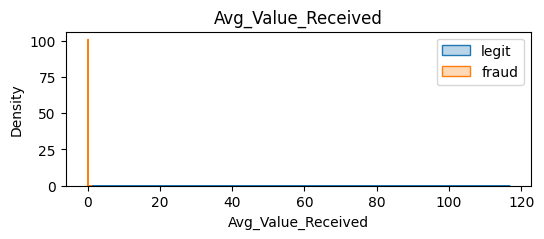

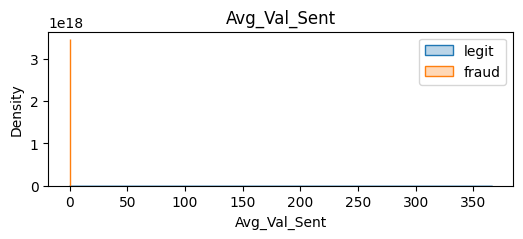

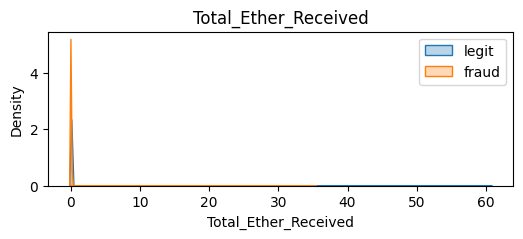

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Допустим, у вас есть flat_feats — DataFrame (n_samples × n_features) и y — метки
flat_feats = df_scaled.drop(columns=['address','step_idx','FLAG'])
labels     = df_scaled['FLAG']

# 1) Сводная таблица: средние и std по каждому признаку
summary = flat_feats.assign(FLAG=labels) \
                    .groupby('FLAG') \
                    .agg(['mean','std']) \
                    .T
display(summary.head(10))

# 2) Гистограммы парочки наиболее важных числовых фичей
for col in ['Avg_Value_Received','Avg_Val_Sent','Total_Ether_Received']:
    plt.figure(figsize=(6,2))
    sns.kdeplot(flat_feats[col][labels==0], label='legit', fill=True, alpha=0.3)
    sns.kdeplot(flat_feats[col][labels==1], label='fraud', fill=True, alpha=0.3)
    plt.title(col); plt.legend(); plt.show()


In [40]:
from sklearn.decomposition import PCA
from sklearn.manifold     import TSNE
import umap

X = flat_feats.values
y = labels.values

# 1) PCA → 2 компоненты
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

# 2) t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_pca)  # сначала PCA для ускорения

# 3) UMAP
X_umap = umap.UMAP(n_components=2, random_state=42).fit_transform(X_pca)

def plot_emb(X_emb, title):
    plt.figure(figsize=(4,4))
    sns.scatterplot(x=X_emb[:,0], y=X_emb[:,1], hue=y, palette=['gray','red'], s=5, alpha=0.7)
    plt.title(title); plt.legend(['legit','fraud']); plt.show()

plot_emb(X_pca,  'PCA')
plot_emb(X_tsne, 't-SNE')
plot_emb(X_umap, 'UMAP')


KeyboardInterrupt: 

In [49]:
from sklearn.cluster import KMeans

# Оставляем только fraud
X_fraud = X[labels==1]
# KMeans с 2–5 кластерами
for k in [2,3,4,5]:
    km = KMeans(n_clusters=k, random_state=42).fit(X_fraud)
    counts = pd.Series(km.labels_).value_counts().sort_index()
    print(f"k={k} → cluster sizes:", counts.values)


k=2 → cluster sizes: [24534   186]
k=3 → cluster sizes: [24451    58   211]
k=4 → cluster sizes: [24451    57   202    10]
k=5 → cluster sizes: [24451    71   179     8    11]


In [50]:
drop_cols = ['address', 'window_start', 'step_idx',
             'scam_type', 'FLAG_NUM', 'is_contract']
feat_df = df.drop(columns=drop_cols)
print("==> Shape после удаления служебных колонок:", feat_df.shape)


==> Shape после удаления служебных колонок: (617370, 36)



===== ТОП-10 столбцов по числу NaN =====


Min_Value_Sent_To_Contract    617161
Max_Value_Sent_To_Contract    617161
Avg_Value_Sent_To_Contract    617161
Min_Val_Sent                  617136
Max_Val_Sent                  617136
Avg_Val_Sent                  617136
Avg_min_between_sent_tnx      617136
ERC20_Avg_Val_Sent            615526
ERC20_Max_Val_Sent            615526
ERC20_Min_Val_Sent            615526
dtype: int64

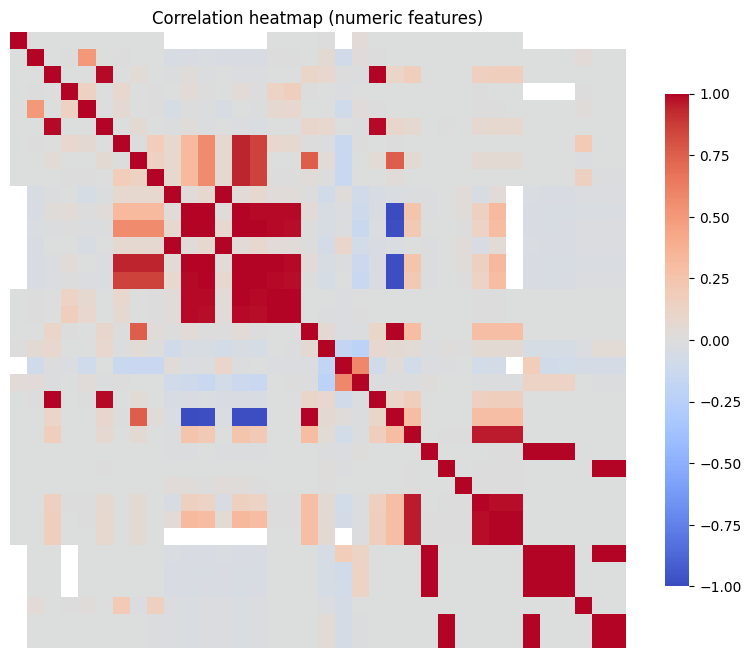


===== Признаки с нулевой дисперсией (n=0) =====
[]

===== Распределение FLAG =====


FLAG
0    96.0
1     4.0
Name: %, dtype: float64

In [51]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns

na_counts = feat_df.isna().sum()
na_nonzero = na_counts[na_counts > 0].sort_values(ascending=False)

print("\n===== ТОП-10 столбцов по числу NaN =====")
display(na_nonzero.head(10))

# 3) Корреляционная матрица Пирсона
num_cols = feat_df.select_dtypes(include=[np.number]).columns.tolist()
corr = feat_df[num_cols].corr(method="pearson")

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0,
            vmax=1, vmin=-1, square=True,
            cbar_kws={"shrink": .8}, xticklabels=False, yticklabels=False)
plt.title("Correlation heatmap (numeric features)")
plt.show()

# 4) Признаки с нулевой дисперсией (постоянные значения)
zero_var = feat_df[num_cols].loc[:, feat_df[num_cols].nunique() == 1].columns.tolist()
print(f"\n===== Признаки с нулевой дисперсией (n={len(zero_var)}) =====")
print(zero_var)

# 5) Быстрый взгляд на распределение классов (FLAG)
print("\n===== Распределение FLAG =====")
display(feat_df["FLAG"].value_counts(normalize=True).rename("%").mul(100).round(2))

In [52]:
import numpy as np

# 1. Определим все числовые признаки (без целевой FLAG)
num_cols = feat_df.select_dtypes(include=[np.number]).columns.drop('FLAG')

# 2. Заполним пропуски нулями
feat_df[num_cols] = feat_df[num_cols].fillna(0)

# 3. Проверим, что пропусков больше нет
print("Осталось NaN всего:", feat_df[num_cols].isna().sum().sum())


Осталось NaN всего: 0


In [53]:
import numpy as np

# все числовые признаки, кроме целевой FLAG
num_feats = feat_df.columns.drop('FLAG')

# log1p: логарифм от (1 + x), чтобы 0→0, 1→0.69 и т. д.
feat_df[num_feats] = np.log1p(feat_df[num_feats])


/Users/a1234/Fraud/.venv/lib/python3.9/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: divide by zero encountered in log1p
  result = func(self.values, **kwargs)
/Users/a1234/Fraud/.venv/lib/python3.9/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)


In [54]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# 1) Выделим все числовые признаки, кроме флага
num_feats = feat_df.columns.drop('FLAG')

# 2) Логарифмирование: log1p сделает 0→0, 1→0.693 и сильно сожмёт большие числа
feat_df[num_feats] = np.log1p(feat_df[num_feats])

# 3) Вместо инфинити ставим 0 (или можно среднее, но 0 здесь безопасно)
feat_df[num_feats].replace([np.inf, -np.inf], 0, inplace=True)

# 4) Если вдруг появились NaN (на всякий случай), снова заполним 0
feat_df[num_feats] = feat_df[num_feats].fillna(0)

# 5) Теперь стандартизация
scaler = StandardScaler()
feat_df[num_feats] = scaler.fit_transform(feat_df[num_feats])

# 6) Проверим
means = feat_df[num_feats].mean().round(3)
stds  = feat_df[num_feats].std().round(3)
print("Средние (≈0):\n", means.head())
print("Сигмы   (≈1):\n", stds.head())
print("NaN осталось:", feat_df[num_feats].isna().sum().sum())
print("Всегда ли конечные:", np.isfinite(feat_df[num_feats]).all().all())


/Users/a1234/Fraud/.venv/lib/python3.9/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)
/var/folders/kb/kq26319d38lbbk7plzy5zdn40000gn/T/ipykernel_9521/1838880011.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  feat_df[num_feats].replace([np.inf, -np.inf], 0, inplace=True)


Средние (≈0):
 Sent_tnx                         -0.0
Received_tnx                     -0.0
Number_of_Created_Contracts      -0.0
Unique_Sent_To_Addresses         -0.0
Unique_Received_From_Addresses    0.0
dtype: float64
Сигмы   (≈1):
 Sent_tnx                          1.0
Received_tnx                      1.0
Number_of_Created_Contracts       1.0
Unique_Sent_To_Addresses          1.0
Unique_Received_From_Addresses    1.0
dtype: float64
NaN осталось: 0
Всегда ли конечные: True


In [55]:
import pandas as pd
import numpy as np

# ——————————————————————————————————————————————
# Предполагаем, что у вас уже есть:
#  df  — исходный df после фильтрации is_contract и маппинга FLAG
# feat_df — тот же df, но без служебных колонок и уже log1p+StandardScaler
# Обе таблички имеют одинаковый индекс строк!
# ——————————————————————————————————————————————

# 1) Возвращаем из feat_df только признаки (без FLAG)
scaled_feats = feat_df.drop(columns=['FLAG'])

# 2) Готовим “склейку” с адресами/step_idx/FLAG из исходного df
df_scaled = (
    df[['address','step_idx','FLAG']]
      .join(scaled_feats)           # по индексу строк
      .reset_index(drop=True)
)

# 3) Оставляем только адреса с ровно 30 шагами
good = df_scaled.groupby('address')['step_idx'].nunique().eq(30)
good_addrs = good[good].index
df_scaled = df_scaled[df_scaled['address'].isin(good_addrs)]

# 4) Сортируем и группируем
features = scaled_feats.columns.tolist()  # список уже отмасштабированных фич
df_scaled = df_scaled.sort_values(['address','step_idx'])

# 5) Строим X и y
X = np.stack(
    df_scaled.groupby('address')[features]
             .apply(lambda g: g.values)
             .to_list()
)
y = df_scaled.groupby('address')['FLAG'].first().to_numpy()

print("Новый X:", X.shape, "  y:", y.shape)
# — теперь X должен быть порядка (20579, 30, 35), но уже без гигантских чисел внутри


Новый X: (20579, 30, 35)   y: (20579,)


In [56]:
from sklearn.model_selection import train_test_split
import numpy as np
from imblearn.pipeline        import Pipeline
from imblearn.over_sampling  import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# === 1) Делим на train / tmp (30% для val+test), сохраняя баланс по y ===
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# === 2) Делим tmp пополам: val и test по 15% от всей выборки ===
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp,
    test_size=0.50,
    stratify=y_tmp,
    random_state=42
)

# === 3) Выведем текущие размеры/баланс ===
def stats(name, Xp, yp):
    n0, n1 = np.bincount(yp)
    total = len(yp)
    print(f"{name}: X={Xp.shape}, y={yp.shape},  класс0={(n0/total*100):.1f}%, класс1={(n1/total*100):.1f}%")

stats("Train before balance", X_train, y_train)
stats("Val           ", X_val,   y_val)
stats("Test          ", X_test,  y_test)

# === 4) Балансировка train-выборки: SMOTE → undersample до 1:1 ===

# 4.1 "Сплющиваем" в 2D
seq_len   = X_train.shape[1]
n_features= X_train.shape[2]
X_flat    = X_train.reshape(X_train.shape[0], -1)

# 4.2 Настраиваем SMOTE (скамы станут 30% от легитов)
smote = SMOTE(sampling_strategy=0.3, random_state=42)

# 4.3 Настраиваем RandomUnderSampler (приводим к 1:1)
rus = RandomUnderSampler(sampling_strategy=1.0, random_state=42)

# 4.4 Собираем пайплайн
balance_pipe = Pipeline([('smote', smote), ('rus', rus)])

# 4.5 Применяем к train
X_flat_res, y_res = balance_pipe.fit_resample(X_flat, y_train)

# 4.6 Возвращаем форму (n_bal, seq_len, n_features)
X_res = X_flat_res.reshape(-1, seq_len, n_features)

# === 5) Выводим новый баланс ===
print("After SMOTE+RUS:", np.bincount(y_res))
stats("Train balanced", X_res, y_res)


Train before balance: X=(14405, 30, 35), y=(14405,),  класс0=96.0%, класс1=4.0%
Val           : X=(3087, 30, 35), y=(3087,),  класс0=96.0%, класс1=4.0%
Test          : X=(3087, 30, 35), y=(3087,),  класс0=96.0%, класс1=4.0%
After SMOTE+RUS: [4148 4148]
Train balanced: X=(8296, 30, 35), y=(8296,),  класс0=50.0%, класс1=50.0%


/Users/a1234/Fraud/.venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/a1234/Fraud/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/a1234/Fraud/.venv/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/a1234/Fraud/.venv/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` in

In [57]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.utils import class_weight
import tensorflow as tf
import tensorflow.keras.backend as K

def focal_loss(gamma=2., alpha=0.25):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        # убираем nan и inf
        y_pred = tf.clip_by_value(y_pred, K.epsilon(), 1.0 - K.epsilon())
        pt = tf.where(tf.equal(y_true, 1), y_pred, 1 - y_pred)
        return -K.mean(alpha * K.pow(1. - pt, gamma) * K.log(pt))
    return loss


# 1) Вычислим взвешивание классов для учёта дисбаланса
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = {0: weights[0], 1: weights[1]}
print("Class weights:", class_weights)

from tensorflow.keras.layers import Masking

model = Sequential([
    Masking(mask_value=0., input_shape=(X_train.shape[1], X_train.shape[2])),
    LSTM(64, return_sequences=True),
    Dropout(0.3),
    LSTM(32),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])


from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.callbacks import EarlyStopping

optimizer = Adam(1e-3)

model.compile(
    optimizer=optimizer,
    loss=focal_loss(gamma=2., alpha=0.25),
    metrics=[
        tf.keras.metrics.AUC(name='AUC'),
        tf.keras.metrics.Precision(name='Precision'),
        tf.keras.metrics.Recall(name='Recall')
    ]
)

callbacks = [
    EarlyStopping(
        monitor='val_AUC', 
        patience=5, 
        mode='max', 
        restore_best_weights=True, 
        verbose=1
    )
]

history = model.fit(
    X_res, y_res,
    epochs=50,                # увеличил до 50, чтобы EarlyStopping успел остановить
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)
val_auc = max(history.history['val_AUC'])
print(f" → best val AUC: {val_auc:.4f}\n")

# 4) Оценка на тесте (return_dict)
test_results = model.evaluate(X_test, y_test, verbose=0, return_dict=True)
test_auc     = test_results['AUC']
print(f"\nTest AUC: {test_auc:.4f}")



Class weights: {0: np.float64(0.5208634654324559), 1: np.float64(12.48266897746967)}


/Users/a1234/Fraud/.venv/lib/python3.9/site-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - AUC: 0.5344 - Precision: 0.5256 - Recall: 0.7077 - loss: 0.0430 - val_AUC: 0.5394 - val_Precision: 0.0434 - val_Recall: 0.9516 - val_loss: 0.0411
Epoch 2/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - AUC: 0.5203 - Precision: 0.5126 - Recall: 0.7704 - loss: 0.0429 - val_AUC: 0.5384 - val_Precision: 0.0433 - val_Recall: 0.9677 - val_loss: 0.0444
Epoch 3/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - AUC: 0.5389 - Precision: 0.5217 - Recall: 0.7772 - loss: 0.0426 - val_AUC: 0.5384 - val_Precision: 0.0433 - val_Recall: 0.9516 - val_loss: 0.0418
Epoch 4/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - AUC: 0.5322 - Precision: 0.5145 - Recall: 0.8998 - loss: 0.0425 - val_AUC: 0.5352 - val_Precision: 0.0434 - val_Recall: 0.9516 - val_loss: 0.0408
Epoch 5/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - AUC: 0.5456 - Precision: 0.5229 - Recall: 0.8351 - loss: 0.0424 - val_AUC: 0.5385 - val_Precision: 0.0435 - val_Recall: 0.9516 - val_loss: 0.

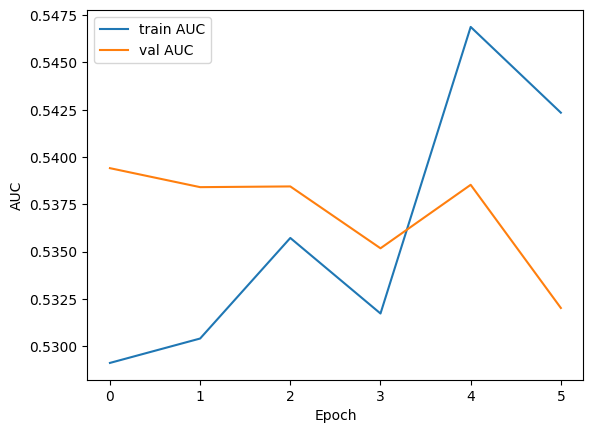

In [58]:
import matplotlib.pyplot as plt

plt.plot(history.history['AUC'], label='train AUC')
plt.plot(history.history['val_AUC'], label='val AUC')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend()
plt.show()


97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


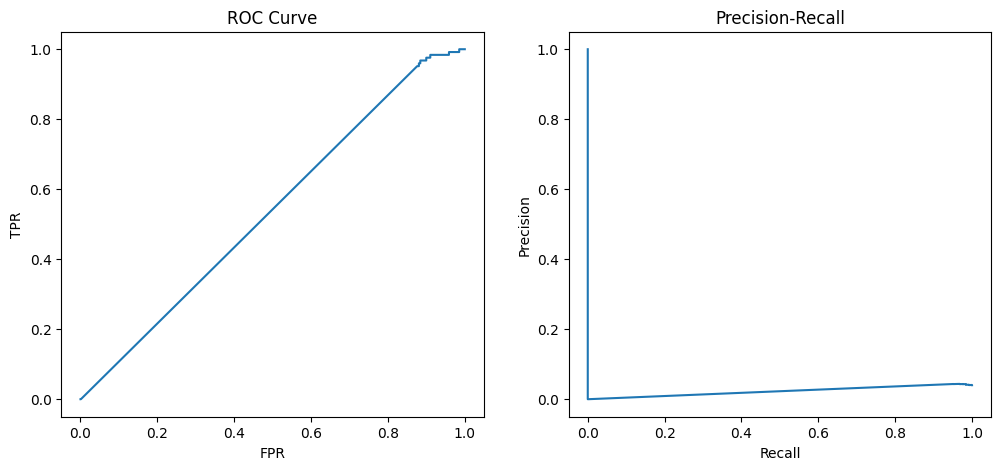


— VALIDATION —
Accuracy : 0.1555
Precision: 0.0434
Recall   : 0.9516
F1-score : 0.0830
Confusion Matrix:
[[ 362 2601]
 [   6  118]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.12      0.22      2963
           1       0.04      0.95      0.08       124

    accuracy                           0.16      3087
   macro avg       0.51      0.54      0.15      3087
weighted avg       0.95      0.16      0.21      3087

97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Best F1: 0.0837988818531335 at threshold: 0.49153805
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


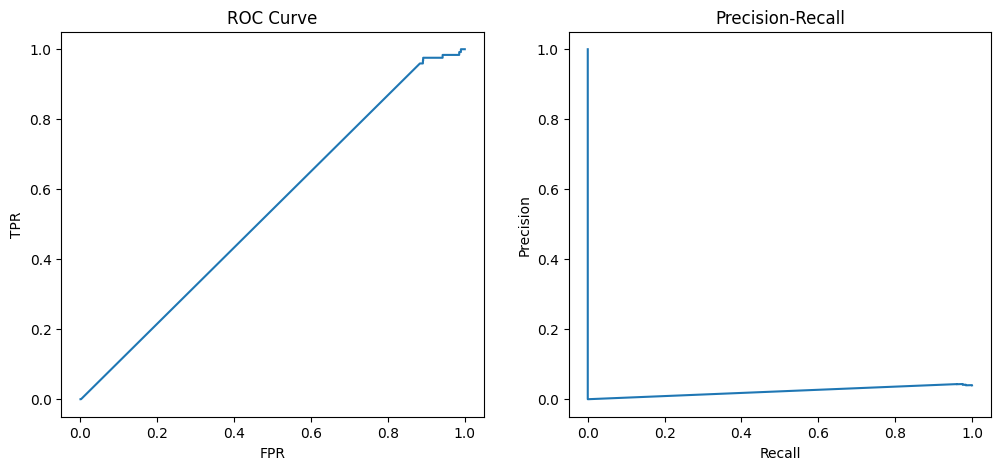


— TEST —
Accuracy : 0.1497
Precision: 0.0431
Recall   : 0.9593
F1-score : 0.0825
Confusion Matrix:
[[ 344 2620]
 [   5  118]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.12      0.21      2964
           1       0.04      0.96      0.08       123

    accuracy                           0.15      3087
   macro avg       0.51      0.54      0.15      3087
weighted avg       0.95      0.15      0.20      3087

97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Best F1: 0.0837988818531335 at threshold: 0.49153805


In [61]:
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix,
    classification_report
)

from sklearn.metrics import roc_curve, precision_recall_curve
import matplotlib.pyplot as plt

def plot_curves(y_true, y_prob):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    prec, rec, _ = precision_recall_curve(y_true, y_prob)

    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(fpr, tpr); plt.title('ROC Curve'); plt.xlabel('FPR'); plt.ylabel('TPR')
    plt.subplot(1,2,2)
    plt.plot(rec, prec); plt.title('Precision-Recall'); plt.xlabel('Recall'); plt.ylabel('Precision')
    plt.show()

from sklearn.metrics import precision_recall_curve

best_threshold = []
# 1) Получаем вероятности и бинарные предсказания
def evaluate_split(name, X_split, y_true):
    # predict возвращает (n_samples, 1)
    y_prob = model.predict(X_split).ravel()
    plot_curves(y_true, y_prob)
    # порог 0.5 → метки 0 или 1
    y_pred = (y_prob >= 0.5).astype(int)
    
    # 2) считаем метрики
    acc   = accuracy_score(y_true, y_pred)
    prec  = precision_score(y_true, y_pred, zero_division=0)
    rec   = recall_score(y_true, y_pred, zero_division=0)
    f1    = f1_score(y_true, y_pred, zero_division=0)
    cm    = confusion_matrix(y_true, y_pred)
    report = classification_report(y_true, y_pred, zero_division=0)
    
    # 3) выводим
    print(f"\n— {name.upper()} —")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print("Confusion Matrix:")
    print(cm)
    print("\nClassification Report:")
    print(report)

    y_prob = model.predict(X_val).ravel()
    prec, rec, thr = precision_recall_curve(y_val, y_prob)
    # Найдём индекс, где F1 макcимальна:
    f1_scores = 2 * prec * rec / (prec + rec + 1e-8)
    best = f1_scores.argmax()
    best_threshold = thr[best]
    print("Best F1:", f1_scores[best], "at threshold:", best_threshold)

# Оцениваем валидацию
# evaluate_split("validation", X_val, y_val)

# # Оцениваем тест
# evaluate_split("test",       X_test, y_test)

# И затем — оценить на валидации и тесте:
evaluate_split("validation", X_val, y_val)
evaluate_split("test",       X_test,  y_test)


In [62]:
# Предсказания на валидации
y_prob = model.predict(X_val).ravel()
y_pred = (y_prob >= best_threshold).astype(int)

# Ищем индексы фп и фн
fp_idx = np.where((y_val==0)&(y_pred==1))[0][:5]
fn_idx = np.where((y_val==1)&(y_pred==0))[0][:5]

print("False Positives (legit→fraud):")
for i in fp_idx:
    print("Address:", df_scaled.address.unique()[i], 
          "step_idx seq:", df_scaled[df_scaled.address==df_scaled.address.unique()[i]].step_idx.values,
          "prob:", y_prob[i])
print("\nFalse Negatives (fraud→legit):")
for i in fn_idx:
    print("Address:", df_scaled.address.unique()[i], "prob:", y_prob[i])


97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


ValueError: operands could not be broadcast together with shapes (3087,) (0,) 

In [ ]:
import shap

# Возьмём компактный набор фич: например, агрегаты
explainer = shap.DeepExplainer(model, X_res[:100])
shap_vals  = explainer.shap_values(X_res[:100])

# Построим summary_plot
shap.summary_plot(shap_vals[0], X_res[:100], feature_names=features)
